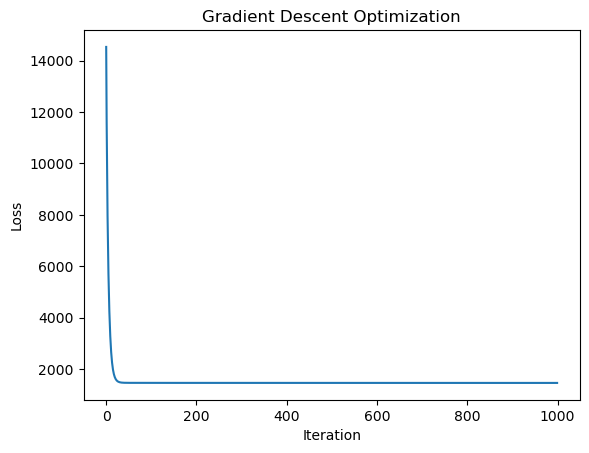

最终损失： 1454.2048187046053


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler

data = load_diabetes()
X_raw = data.data
y = data.target

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
X = np.c_[np.ones(X.shape[0]), X]

class MSELoss:
    def __init__(self, reg=0.0):
        self.reg = reg
    def loss(self, X, y, w):
        n = len(y)
        pred = X @ w
        error = pred - y
        mse = np.sum(error ** 2) / (2 * n)
        reg_loss = self.reg * np.sum(w[1:] ** 2)
        return mse + reg_loss
    def grad(self, X, y, w):
        n = len(y)
        pred = X @ w
        error = pred - y
        grad = X.T @ error / n
        grad[1:] += 2 * self.reg * w[1:]
        return grad

class GradientDescent:
    def __init__(self, lr=0.1):
        self.lr = lr
    def step(self, w, grad):
        return w - self.lr * grad

w = np.zeros(X.shape[1])
loss_fn = MSELoss(reg=0.01)
optimizer = GradientDescent(lr=0.1)
loss_history = []
for i in range(1000):
    loss = loss_fn.loss(X, y, w)
    grad = loss_fn.grad(X, y, w)
    w = optimizer.step(w, grad)
    loss_history.append(loss)

plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Gradient Descent Optimization")
plt.savefig('loss_curve.png')
plt.show()
print("最终损失：", loss_history[-1])